# Create ACT MASK in Healpix:

**Edmond:** I do this within the kszx environment. You don't need to use kszx to do this but I will use the I/O from there for pixell. (https://github.com/echaussidon/kszx)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import pixell

from regressis.plot import plot_moll

def pixell_to_healpix(pixell_map, nside=256, nest=False):
    """
    Convert a pixell map to HEALPix format.
    
    Parameters:
    -----------
    pixell_map : enmap
        Input pixell map
    nside : int
        HEALPix resolution parameter (must be power of 2)
    nest : bool
        If False, use RING ordering; if True, use NESTED ordering
    
    Returns:
    --------
    healpix_map : ndarray
        HEALPix map array in NESTED order !
    """
    # Get map shape and geometry
    shape, wcs = pixell_map.shape, pixell_map.wcs
    
    # Create HEALPix map
    npix = hp.nside2npix(nside)
    healpix_map = np.zeros(npix)
    
    # Get HEALPix pixel coordinates
    theta, phi = hp.pix2ang(nside, np.arange(npix), nest=nest)
    
    # Convert spherical coordinates to sky coordinates (ra, dec)
    ra = np.degrees(phi)
    dec = 90 - np.degrees(theta)
    
    # Map HEALPix coordinates to pixell map coordinates
    y, x = pixell.enmap.sky2pix(shape, wcs, np.array([np.radians(dec), np.radians(ra)]))
    
    # Interpolate pixell map values at HEALPix pixel locations
    from scipy.ndimage import map_coordinates
    valid = (x >= 0) & (x < shape[-1]) & (y >= 0) & (y < shape[-2])
    healpix_map[valid] = map_coordinates(pixell_map, [y[valid], x[valid]], order=1, mode='constant', cval=0)
    
    return hp.reorder(healpix_map, r2n=True)

In [2]:
import kszx

# for plotting purpose --> just with 90 channel --> OK!

cmb = kszx.act.read_cmb(freq=90, dr=6, download=True)
ivar = kszx.act.read_ivar(freq=90, dr=6, download=True)

# galmask_sky_percentage = 70
mask_gal = kszx.pixell_utils.read_map('/pscratch/sd/e/edmondc/kszx_data/pipelines/desi/dr2/lrg_ngc_input/tmp/pixell_galmask.fits')

mask = kszx.pixell_utils.uK_arcmin_from_ivar(ivar) < 70 # uK-arcmin
mask = mask * mask_gal

MPI startup(): FI_PSM3_UUID was not generated, please set it to avoid possible resources ownership conflicts between MPI processes
kszx: environment variable $KSZX_DATA_DIR not defined, using /global/homes/e/edmondc/kszx_data instead
Reading /global/homes/e/edmondc/kszx_data/act/dr6.02/maps/published/act-planck_dr6.02_coadd_AA_daynight_f090_map_srcfree.fits
Reading /global/homes/e/edmondc/kszx_data/act/dr6.02/maps/published/act-planck_dr6.02_coadd_AA_daynight_f090_ivar.fits
Reading /pscratch/sd/e/edmondc/kszx_data/pipelines/desi/dr2/lrg_ngc_input/tmp/pixell_galmask.fits


/global/homes/e/edmondc/.conda/envs/kszx/lib/python3.12/site-packages/healpy/visufunc.py:764: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


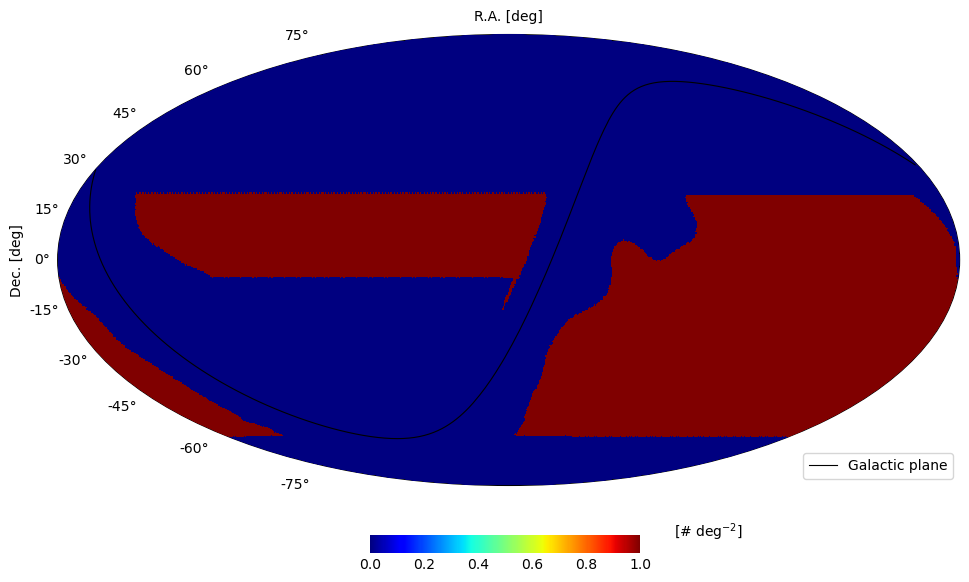

In [3]:
mask_healpix = pixell_to_healpix(mask)
mask_healpix = hp.ud_grade(hp.ud_grade(mask_healpix, order_in='NESTED', nside_out=128), order_in='NESTED', nside_out=256)
mask_healpix[mask_healpix > 0] = 1

plot_moll(mask_healpix, min=0, max=1)

In [ ]:
import fitsio

# Écriture avec fitsio (image HDU)
#fitsio.write('Act_dr6_mask_256.fits', mask_healpix, extname='MASK', clobber=True)

print(fitsio.FITS('Act_dr6_mask_256.fits')['MASK'][:])

array([1., 1., 1., ..., 1., 1., 1.], shape=(786432,))

/global/homes/e/edmondc/.conda/envs/kszx/lib/python3.12/site-packages/healpy/visufunc.py:764: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


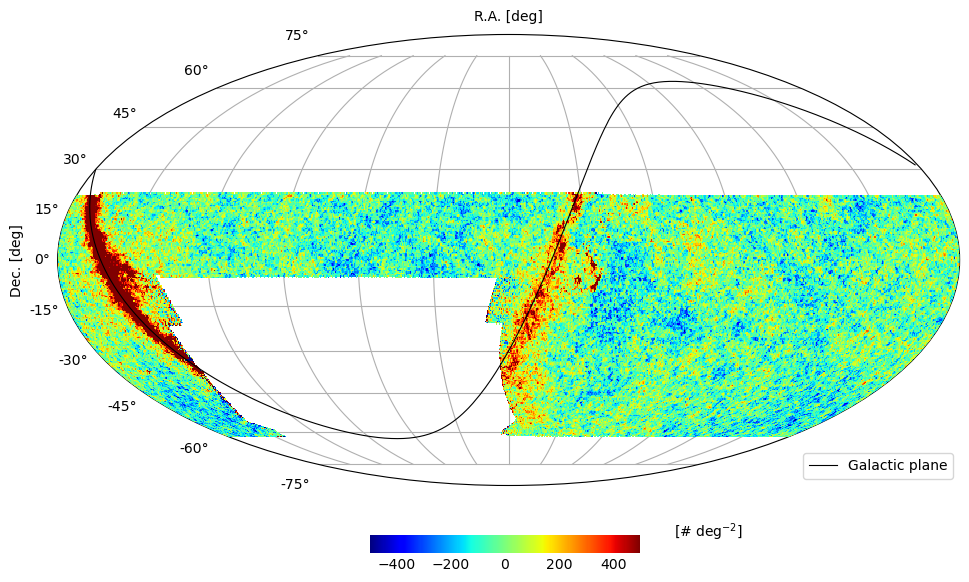

/global/homes/e/edmondc/.conda/envs/kszx/lib/python3.12/site-packages/healpy/visufunc.py:764: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


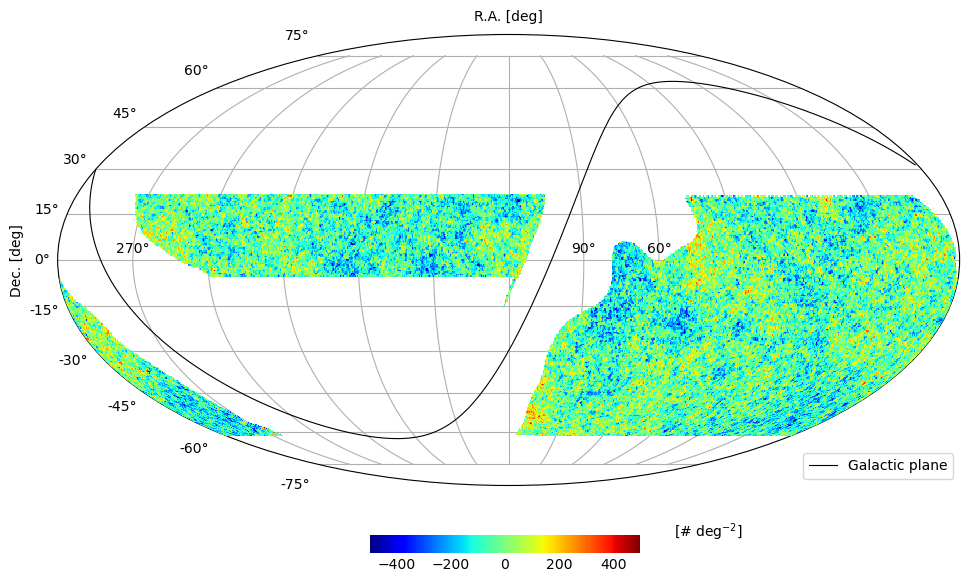

In [8]:
test1 = pixell_to_healpix(cmb)
test2 = pixell_to_healpix(cmb * mask)

test1[test1 == 0] = hp.UNSEEN
test2[test2 == 0] = hp.UNSEEN

plot_moll(test1, min=-500,max=500)
plot_moll(test2, min=-500, max=500)

<Figure size 640x480 with 0 Axes>

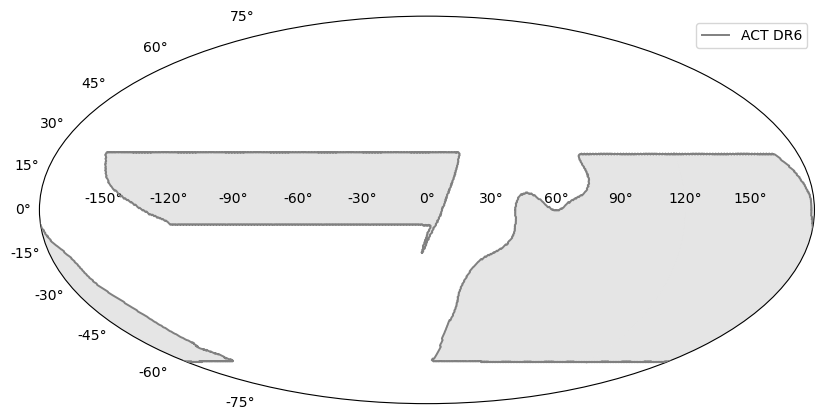

In [13]:
rot = 120

plt.figure()
fig, ax = plt.subplots(subplot_kw={'projection': 'mollweide'}, figsize=(10,6))

from pathlib import Path
from skimage import measure
from matplotlib.patches import Polygon
import fitsio
 
toplot = hp.reorder(fitsio.FITS('Act_dr6_mask_256.fits')['MASK'][:], n2r=True)
nside = hp.npix2nside(toplot.size)

# ==== MAKE A RA/DEC GRID TO SAMPLE FOOTPRINT ====
nra, ndec = 1800, 900  # ~0.2° resolution
ra_grid = np.linspace(0, 360, nra, endpoint=False)
dec_grid = np.linspace(-90, 90, ndec)

RA2D, DEC2D = np.meshgrid(ra_grid, dec_grid[::-1])
theta, phi = np.radians(90 - DEC2D), np.radians(RA2D)

vecs = hp.ang2vec(theta.ravel(), phi.ravel())
pix = hp.vec2pix(nside, vecs[:,0], vecs[:,1], vecs[:,2])
sampled = toplot[pix].reshape(DEC2D.shape)

# ==== FIND CONTOURS IN SAMPLE GRID ====
contours = measure.find_contours(sampled.astype(float), 0.5)

vertices = []
for c in contours:
    rows, cols = c[:,0], c[:,1]
    decs = np.interp(rows, np.arange(sampled.shape[0]), dec_grid[::-1])
    ras  = np.interp(cols, np.arange(sampled.shape[1]), ra_grid)
    vertices += [np.column_stack([np.radians(ras), np.radians(decs)])]

for verts in vertices:
    verts = verts.copy().T
    verts[0] = np.radians(rot)-verts[0] 
    verts = verts.T
    ax.plot(verts[:,0], verts[:,1], color='gray', alpha=1, lw=1.4, zorder=100)
    poly = Polygon(verts, closed=True, facecolor='gray', alpha=0.2, hatch='')
    ax.add_patch(poly)

for verts in [vertices[2]]:
    verts = verts.copy().T
    verts[0] = np.radians(rot) - verts[0] + 2*np.pi - 0.004  # we cheat a bit -> slide to the left to fill the edge of the Polygon that left a white space...
    verts = verts.T
    ax.plot(verts[:,0], verts[:,1], color='gray', alpha=1, lw=1.4, label='ACT DR6', zorder=100)
    poly = Polygon(verts, closed=True, facecolor='gray', alpha=0.2, hatch='')
    ax.add_patch(poly)

plt.legend()
plt.show()
